<a href="https://colab.research.google.com/github/yessiontherise/Analisis-Komentar-Video-Tiktok-Pemerintah-Blora/blob/main/analisisKomenVideoTiktok.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**INSTALL LIBRARIES**

In [ ]:
!pip -q install pandas numpy requests regex ftfy rapidfuzz
!pip -q install scikit-learn matplotlib tqdm
!pip -q install transformers datasets accelerate evaluate sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.8 MB/s eta 0:00:00


**INSTALL LIBRARIES**

In [ ]:
import os, re, time
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

from getpass import getpass
from collections import Counter
import regex as regx
import ftfy
from tqdm.auto import tqdm

**CONFIG TOKEN & PARAMETER**

In [ ]:
ACTOR_ID  = "GdWCkxBtKWOsKjdch"
VIDEO_URL = "https://www.tiktok.com/@ini_infoblora/video/7538982014687448326"

MAX_COMMENTS   = 500
SCRAPE_REPLIES = False

APIFY_TOKEN = os.getenv("APIFY_TOKEN")
if not APIFY_TOKEN:
    APIFY_TOKEN = getpass("Masukkan APIFY_TOKEN: ")

print("✅ Config OK")

Masukkan APIFY_TOKEN: ··········
✅ Config OK


**SCRAPING APIFY**

In [ ]:
def apify_scrape_comments_sync(actor_id, video_url, token, max_comments=500, scrape_replies=False, timeout=300):
    url = f"https://api.apify.com/v2/acts/{actor_id}/run-sync-get-dataset-items"
    headers = {"Authorization": f"Bearer {token}", "Content-Type": "application/json"}

    payload = {
        "postURLs": [video_url],
        "commentsPerPost": int(max_comments),
        "scrapeReplies": bool(scrape_replies),
        # proxy membantu stabilitas (kalau akunmu support)
        "proxyConfiguration": {"useApifyProxy": True},
    }

    res = requests.post(url, headers=headers, json=payload, timeout=timeout)
    res.raise_for_status()
    meta = pd.DataFrame(res.json())

    if "commentsDatasetUrl" not in meta.columns:
        raise RuntimeError("❌ Output tidak mengandung commentsDatasetUrl. Actor tidak mengeluarkan dataset komentar.")

    comments_url = meta.loc[0, "commentsDatasetUrl"]
    if not isinstance(comments_url, str) or comments_url.strip() == "" or comments_url.lower() == "none":
        raise RuntimeError("❌ commentsDatasetUrl kosong/None. Comments belum keluar dari actor.")

    # download comments dataset
    rc = requests.get(comments_url, timeout=timeout)
    rc.raise_for_status()
    cdf = pd.DataFrame(rc.json())

    if "text" not in cdf.columns:
        raise KeyError(f"❌ Kolom 'text' tidak ditemukan. Kolom yang ada: {cdf.columns.tolist()[:60]}")

    out = cdf[["text"]].rename(columns={"text": "comment_text"}).dropna()
    out["comment_text"] = out["comment_text"].astype(str)
    return out

# === RUN SCRAPING dengan fallback ===
try:
    comments_df = apify_scrape_comments_sync(ACTOR_ID, VIDEO_URL, APIFY_TOKEN, MAX_COMMENTS, SCRAPE_REPLIES, timeout=300)
except requests.exceptions.ReadTimeout:
    print("⚠️ Timeout. Coba lebih ringan: comments=200, replies=False")
    comments_df = apify_scrape_comments_sync(ACTOR_ID, VIDEO_URL, APIFY_TOKEN, 200, False, timeout=300)
except requests.exceptions.HTTPError as e:
    print("❌ HTTPError:", e)
    raise

comments_df.to_csv("komentar_tiktok_raw.csv", index=False, encoding="utf-8-sig")
print("✅ SCRAPING SELESAI -> komentar_tiktok_raw.csv | rows:", len(comments_df))
comments_df.head()

✅ SCRAPING SELESAI -> komentar_tiktok_raw.csv | rows: 500


,comment_text
0,"baca komen seneng banget, banyak yang protes s..."
1,Artinya desa ini sudah komitmen presiden selan...
2,2029 Gibran Rakabumi Raka
3,"ada anak Singapore ,layar hpnya photo pak joko..."
4,apakah betul itu presiden ke 9 Gibran Rakabuming


**Data Loading**

In [ ]:
df = pd.read_csv("komentar_tiktok_raw.csv")
df.dropna(subset=["comment_text"], inplace=True)
df["comment_text"] = df["comment_text"].astype(str)
print("Jumlah komentar raw:", len(df))
df.head()

Jumlah komentar raw: 499


,comment_text
0,"baca komen seneng banget, banyak yang protes s..."
1,Artinya desa ini sudah komitmen presiden selan...
2,2029 Gibran Rakabumi Raka
3,"ada anak Singapore ,layar hpnya photo pak joko..."
4,apakah betul itu presiden ke 9 Gibran Rakabuming


**Cleaning**

In [ ]:
EMOJI_MAP = {
    "😂":" ketawa ","🤣":" ketawa ",
    "😭":" sedih ","😢":" sedih ",
    "❤️":" cinta ","😍":" suka ",
    "🔥":" keren ","😡":" marah ","🙏":" terima_kasih "
}

URL_PAT = re.compile(r"http\S+|www\.\S+", re.IGNORECASE)
MENTION_PAT = re.compile(r"@\w+")
HASHTAG_PAT = re.compile(r"#\w+")
LAUGH_PAT = re.compile(r"\b(wk+w*k*|wkwk+|haha+|hihi+|hehe+|xix+i+)\b", re.IGNORECASE)
MULTISPACE = re.compile(r"\s+")
REPEAT_CHAR = re.compile(r"(.)\1{2,}")

# Jawa->Indo (tambahkan sesuai komentar yang kamu lihat)
JV2ID = {
    "ora":"tidak","ra":"tidak","ndak":"tidak",
    "wis":"sudah","wes":"sudah",
    "apik":"bagus","piye":"gimana","opo":"apa",
    "kowe":"kamu","koe":"kamu",
    "yo":"iya","iyo":"iya","nggih":"iya"
}

# slang/typo umum Indo (tambahkan sesuai data)
NORM = {
    "gk":"tidak","ga":"tidak","gak":"tidak","nggak":"tidak","tdk":"tidak",
    "bgt":"banget","bgtt":"banget",
    "kerenn":"keren","kereen":"keren","kereeen":"keren","krenn":"keren","kerennn":"keren",
    "mantapp":"mantap","mntap":"mantap",
    "bgus":"bagus","bgs":"bagus"
}

STOPWORDS = set("""
yang yg dan di ke dari untuk pada dengan ini itu atau karena sebagai juga saja sih
nya nih tuh ya kok dong aja aku kamu dia mereka kita dalam akan sudah belum sangat lebih jadi
pak mas bu ibu admin min
""".split())

def normalize_emoji(text: str) -> str:
    for e,w in EMOJI_MAP.items():
        text = text.replace(e, w)
    return text

def squash_repeat(text: str) -> str:
    return REPEAT_CHAR.sub(r"\1\1", text)

def clean_text_and_tokens(text: str):
    t = ftfy.fix_text(str(text)).replace("\n"," ").replace("\t"," ").strip().lower()
    t = normalize_emoji(t)

    t = URL_PAT.sub(" ", t)
    t = MENTION_PAT.sub(" ", t)
    t = HASHTAG_PAT.sub(lambda m: " " + m.group(0)[1:] + " ", t)
    t = LAUGH_PAT.sub(" ketawa ", t)

    # angka -> token <num> (boleh dibuang nanti saat topik)
    t = regx.sub(r"\p{N}+", " <num> ", t)

    t = squash_repeat(t)
    t = regx.sub(r"[^\p{L}\s<>_]", " ", t)  # keep letters + tokens
    t = MULTISPACE.sub(" ", t).strip()

    toks = []
    for w in t.split():
        w = JV2ID.get(w, w)
        w = NORM.get(w, w)
        if w in STOPWORDS:
            continue
        if len(w) < 3 and w not in {"<num>"}:
            continue
        toks.append(w)

    cleaned = " ".join(toks).strip()
    return cleaned, toks

df["clean_text"], df["tokens"] = zip(*df["comment_text"].apply(clean_text_and_tokens))
df = df[df["clean_text"].str.len() > 0].copy()

df.to_csv("komentar_tiktok_clean.csv", index=False, encoding="utf-8-sig")
print("✅ Cleaning selesai -> komentar_tiktok_clean.csv | rows:", len(df))
df[["comment_text","clean_text"]].head(8)

✅ Cleaning selesai -> komentar_tiktok_clean.csv | rows: 457


,comment_text,clean_text
0,"baca komen seneng banget, banyak yang protes s...",baca komen seneng banget banyak protes soal ga...
1,Artinya desa ini sudah komitmen presiden selan...,artinya desa komitmen presiden selanjutnya pil...
2,2029 Gibran Rakabumi Raka,<num> gibran rakabumi raka
3,"ada anak Singapore ,layar hpnya photo pak joko...",ada anak singapore layar hpnya photo jokowi ke...
4,apakah betul itu presiden ke 9 Gibran Rakabuming,apakah betul presiden <num> gibran rakabuming
5,next Gibran 2029 jdi Presiden 🥰🥰,next gibran <num> jdi presiden
6,Iki tak ulang yaa semua itu presiden kecuali g...,iki tak ulang yaa semua presiden kecuali gibra...
7,"BPK Soekarno, Soeharto,pak Jokowi selalu di ha...",bpk soekarno soeharto jokowi selalu hati suka


**EDA**

count    457.000000
mean       5.728665
std        5.333680
min        1.000000
25%        2.000000
50%        4.000000
75%        7.000000
max       38.000000
Name: word_count, dtype: float64


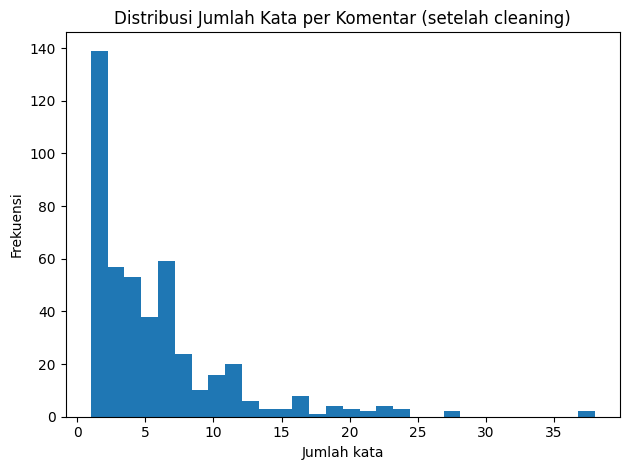


Top 20 kata (global topik):
keren 180
ketawa 95
gibran 66
tidak 52
presiden 51
banget 44
cinta 42
ada 41
suka 36
terima_kasih 25
indonesia 22
jokowi 20
bagus 20
anis 18
rakyat 17
kreatif 17
mantap 15
desa 14
sedih 14
foto 12

Top 20 bigram (global topik):
ketawa ketawa 58
keren keren 39
cinta cinta 29
tidak ada 23
keren banget 19
suka suka 16
luar biasa 10
terima_kasih terima_kasih 9
masya allah 8
anis tidak 7
bagus banget 7
gibran presiden 6
wakil presiden 6
foto anis 5
kreatif banget 5
next gibran 4
pilihan rakyat 4
ada gibran 4
ada foto 4
wow keren 4


In [ ]:
dfc = pd.read_csv("komentar_tiktok_clean.csv")
dfc["word_count"] = dfc["clean_text"].astype(str).str.split().apply(len)

print(dfc["word_count"].describe())

plt.figure()
plt.hist(dfc["word_count"], bins=30)
plt.title("Distribusi Jumlah Kata per Komentar (setelah cleaning)")
plt.xlabel("Jumlah kata"); plt.ylabel("Frekuensi")
plt.tight_layout(); plt.show()

# Topik global: buang token noise <num> untuk topik
all_tokens = []
for toks in dfc["tokens"]:
    # toks disimpan sebagai list? (kalau kebaca string, split)
    if isinstance(toks, str):
        toks = toks.strip("[]")
        toks = re.findall(r"[a-zA-Z<>_]+", toks)
    toks = [t for t in toks if t != "<num>"]
    all_tokens.extend(toks)

top_words = Counter(all_tokens).most_common(20)
print("\nTop 20 kata (global topik):")
for w,cnt in top_words:
    print(w, cnt)

# Bigram
def top_bigrams(texts, topk=20):
    c = Counter()
    for t in texts:
        toks = str(t).split()
        toks = [x for x in toks if x != "<num>"]
        for i in range(len(toks)-1):
            c[f"{toks[i]} {toks[i+1]}"] += 1
    return c.most_common(topk)

print("\nTop 20 bigram (global topik):")
for w,cnt in top_bigrams(dfc["clean_text"].tolist(), 20):
    print(w, cnt)

**Labeling**

In [ ]:
import pandas as pd

dfc = pd.read_csv("komentar_tiktok_clean.csv")

print("Jumlah data:", len(dfc))
dfc.head()

Jumlah data: 457


,comment_text,clean_text,tokens
0,"baca komen seneng banget, banyak yang protes s...",baca komen seneng banget banyak protes soal ga...,"['baca', 'komen', 'seneng', 'banget', 'banyak'..."
1,Artinya desa ini sudah komitmen presiden selan...,artinya desa komitmen presiden selanjutnya pil...,"['artinya', 'desa', 'komitmen', 'presiden', 's..."
2,2029 Gibran Rakabumi Raka,<num> gibran rakabumi raka,"['<num>', 'gibran', 'rakabumi', 'raka']"
3,"ada anak Singapore ,layar hpnya photo pak joko...",ada anak singapore layar hpnya photo jokowi ke...,"['ada', 'anak', 'singapore', 'layar', 'hpnya',..."
4,apakah betul itu presiden ke 9 Gibran Rakabuming,apakah betul presiden <num> gibran rakabuming,"['apakah', 'betul', 'presiden', '<num>', 'gibr..."


In [ ]:
from transformers import pipeline

# load model pretrained IndoBERT sentiment
classifier = pipeline(
    "text-classification",
    model="w11wo/indonesian-roberta-base-sentiment-classifier",
    tokenizer="w11wo/indonesian-roberta-base-sentiment-classifier"
)

# prediksi
results = classifier(dfc["clean_text"].astype(str).tolist(), truncation=True)

dfc["sentimen"] = [r["label"].lower() for r in results]

dfc["sentimen"].value_counts()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: w11wo/indonesian-roberta-base-sentiment-classifier
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,count
sentimen,
positive,234
negative,112
neutral,111


**Visualisasi Distribusi**

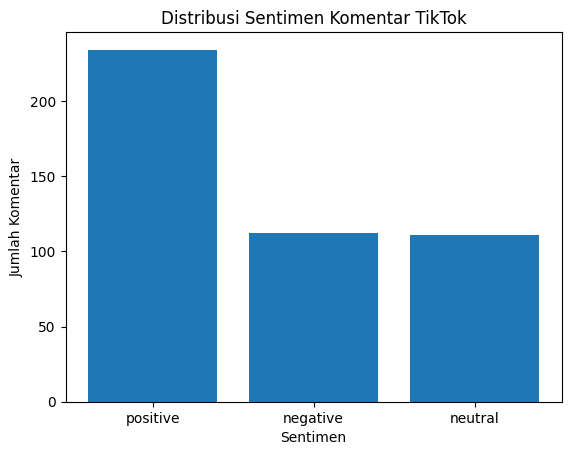


Persentase:
sentimen
positive    51.20
negative    24.51
neutral     24.29
Name: count, dtype: float64


In [ ]:
import matplotlib.pyplot as plt

sent_counts = dfc["sentimen"].value_counts()

plt.figure()
plt.bar(sent_counts.index, sent_counts.values)
plt.title("Distribusi Sentimen Komentar TikTok")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah Komentar")
plt.show()

print("\nPersentase:")
print((sent_counts / len(dfc) * 100).round(2))

In [ ]:
from collections import Counter

STOP_EXTRA = set("""
ada tidak bukan mau siapa buat presiden gibran jokowi anis rakyat foto pilih
""".split())

In [ ]:
from collections import Counter

def top_words_by_sentiment_clean(df, sentiment, topk=15):
    texts = df[df["sentimen"] == sentiment]["clean_text"]
    tokens = []
    for t in texts:
        toks = str(t).split()
        toks = [
            x for x in toks
            if x != "<num>"
            and x not in STOP_EXTRA
            and len(x) > 3
        ]
        tokens.extend(toks)
    return Counter(tokens).most_common(topk)

for s in dfc["sentimen"].unique():
    print(f"\nTop kata untuk sentimen {s.upper()}:")
    for w,cnt in top_words_by_sentiment(dfc, s):
        print(w, cnt)


Top kata untuk sentimen NEGATIVE:
ketawa 66
tidak 31
ada 21
presiden 16
gibran 15
rakyat 10
anis 10
sedih 9
bukan 7
indonesia 7
mau 6
pajang 6
suka 5
hati 5
siapa 5

Top kata untuk sentimen NEUTRAL:
gibran 29
presiden 26
ketawa 21
ada 13
tidak 13
terima_kasih 10
jokowi 9
foto 6
pilih 6
raka 5
keren 5
anis 5
buat 5
megawati 5
rakyat 5

Top kata untuk sentimen POSITIVE:
keren 172
cinta 42
banget 41
suka 30
gibran 22
bagus 18
mantap 15
terima_kasih 13
indonesia 12
biasa 11
kreatif 10
luar 10
presiden 9
merdeka 9
jokowi 8


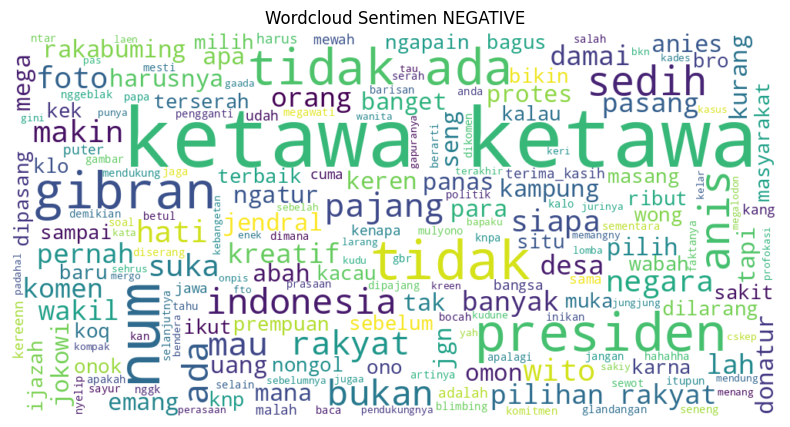

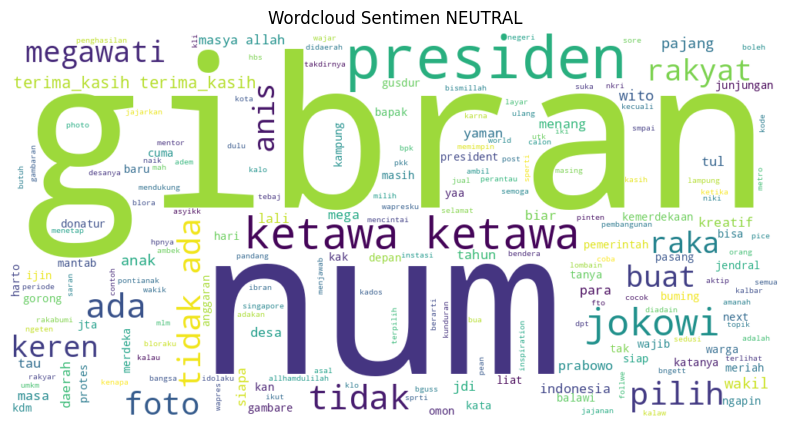

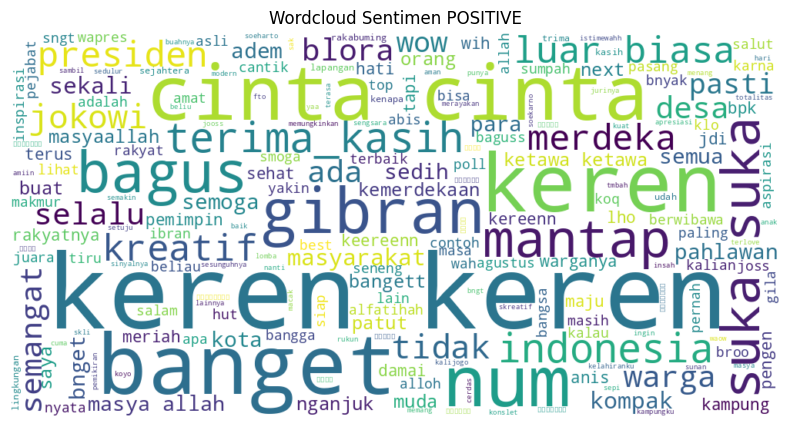

In [ ]:
from wordcloud import WordCloud

for s in dfc["sentimen"].unique():
    text = " ".join(dfc[dfc["sentimen"] == s]["clean_text"])
    wc = WordCloud(width=1000, height=500, background_color="white").generate(text)

    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Wordcloud Sentimen {s.upper()}")
    plt.show()